In [29]:
# Required Imports
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

from src.utils.data_processor import fetch_credit_card_data, engineer_risk_features, prepare_model_data
from src.models.logistic_risk_model import LogisticRiskEstimator
from src.models.decision_tree_risk_model import DecisionTreeRiskEstimator
from src.models.knn_risk_model import KNNRiskEstimator
from src.models.naive_bayes_risk_model import NaiveBayesRiskEstimator
from src.models.random_forest_risk_model import RandomForestRiskEstimator

print("✅ All imports successful!")

✅ All imports successful!


In [30]:
# Load and Prepare Data
print("\n" + "="*60)
print("STEP 1: Loading and Preparing Data")
print("="*60)

df = fetch_credit_card_data('data/credit_card_default.xls')
df = engineer_risk_features(df)
X_train, X_test, y_train, y_test, scaler = prepare_model_data(df)

os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler.joblib')
feature_cols = X_train.columns.tolist()
joblib.dump(feature_cols, 'models/feature_columns.joblib')

print(f"✅ Data loaded successfully!")
print(f"   Training samples: {len(X_train)}, Test samples: {len(X_test)}")
print(f"   Default rate in train: {y_train.mean():.2%}")
print(f"   Default rate in test: {y_test.mean():.2%}")

# Get unique classes for confusion matrix labels
class_labels = sorted(y_test.unique())
print(f"   Classes: {class_labels}")


STEP 1: Loading and Preparing Data
✅ Data loaded successfully!
   Training samples: 24000, Test samples: 6000
   Default rate in train: 22.12%
   Default rate in test: 22.12%
   Classes: [np.int64(0), np.int64(1)]


In [31]:
# Train and Save All 5 Models
print("\n" + "="*60)
print("STEP 2: Training and Saving All Models")
print("="*60)

model_configs = [
    ("Logistic Regression", LogisticRiskEstimator, {'random_seed': 2026}),
    ("Decision Tree", DecisionTreeRiskEstimator, {'random_seed': 2026, 'max_depth': 10, 'min_samples_split': 50}),
    ("KNN", KNNRiskEstimator, {'random_seed': 2026, 'n_neighbors': 15, 'weights': 'distance'}),
    ("Naive Bayes", NaiveBayesRiskEstimator, {'random_seed': 2026}),
    ("Random Forest", RandomForestRiskEstimator, {'random_seed': 2026, 'n_estimators': 100, 'max_depth': 15, 'min_samples_split': 50})
]

models = {}

for name, estimator_class, params in model_configs:
    print(f"\nTraining {name}...")
    model = estimator_class(**params)
    model.train(X_train, y_train)

    filename = f"models/{name.lower().replace(' ', '_')}_v1.joblib"
    joblib.dump(model, filename)
    models[name] = model
    print(f"   ✅ {name} saved to {filename}")

print("\n✅ All 5 models trained and saved successfully!")


STEP 2: Training and Saving All Models

Training Logistic Regression...
   ✅ Logistic Regression saved to models/logistic_regression_v1.joblib

Training Decision Tree...
   ✅ Decision Tree saved to models/decision_tree_v1.joblib

Training KNN...
   ✅ KNN saved to models/knn_v1.joblib

Training Naive Bayes...
   ✅ Naive Bayes saved to models/naive_bayes_v1.joblib

Training Random Forest...
   ✅ Random Forest saved to models/random_forest_v1.joblib

✅ All 5 models trained and saved successfully!


In [32]:
# Evaluate All Models
print("\n" + "="*60)
print("STEP 3: Evaluating All Models on Test Set")
print("="*60)

results = {}
confusion_matrices = {}
reports = {}

for name, model in models.items():
    y_pred = model.forecast_default_class(X_test)
    y_proba = model.forecast_default_proba(X_test)

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, y_proba),
        'Precision': precision_score(y_test, y_pred, average='weighted'),
        'Recall': recall_score(y_test, y_pred, average='weighted'),
        'F1 Score': f1_score(y_test, y_pred, average='weighted'),
        'MCC': matthews_corrcoef(y_test, y_pred)
    }
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)
    reports[name] = classification_report(y_test, y_pred, target_names=[str(c) for c in class_labels])
    print(f"   ✅ {name} evaluated.")


STEP 3: Evaluating All Models on Test Set
   ✅ Logistic Regression evaluated.
   ✅ Decision Tree evaluated.
   ✅ KNN evaluated.
   ✅ Naive Bayes evaluated.
   ✅ Random Forest evaluated.


In [33]:
# Display Comparison Table
print("\n" + "="*80)
print("MODEL COMPARISON TABLE")
print("="*80)

df_results = pd.DataFrame(results).T
df_results = df_results.round(4)

# Reorder columns to match your screenshot: Accuracy, Precision, Recall, F1, MCC, AUC
df_results = df_results[['Accuracy', 'Precision', 'Recall', 'F1 Score', 'MCC', 'AUC']]

# Display as a clean table with highlighting
print(df_results.to_string())

# Save to CSV
df_results.to_csv('model_comparison.csv')
print("\n✅ Results saved to model_comparison.csv")


MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1 Score     MCC     AUC
Logistic Regression    0.6922     0.7712  0.6922    0.7154  0.3121  0.7435
Decision Tree          0.7120     0.7732  0.7120    0.7315  0.3248  0.7427
KNN                    0.8123     0.7929  0.8123    0.7923  0.3773  0.7516
Naive Bayes            0.6418     0.7771  0.6418    0.6723  0.3024  0.7555
Random Forest          0.7687     0.7923  0.7687    0.7778  0.3922  0.7874

✅ Results saved to model_comparison.csv



CONFUSION MATRICES

Logistic Regression:


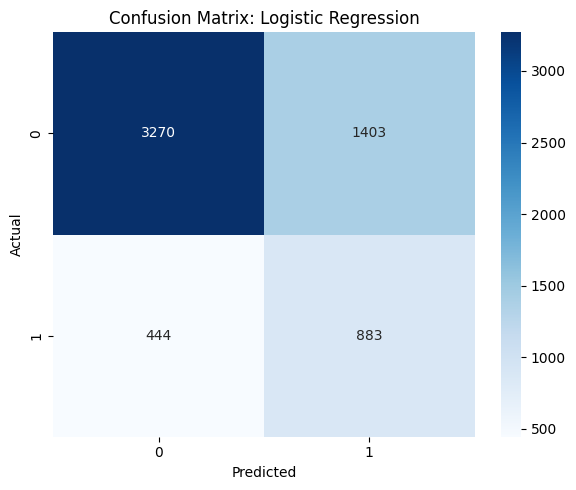


Decision Tree:


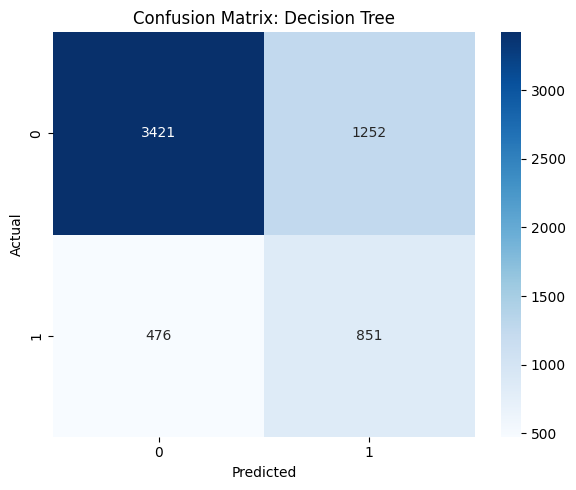


KNN:


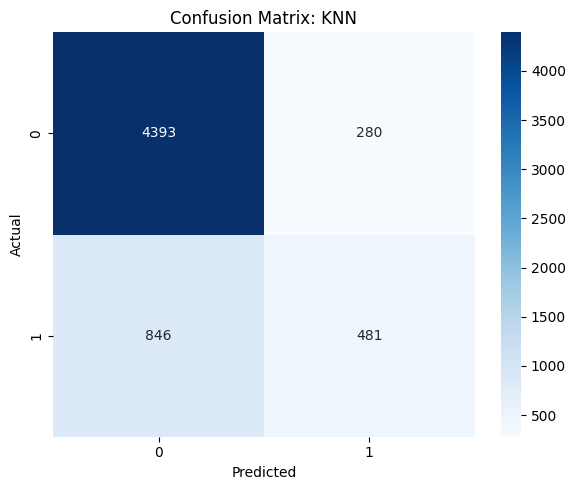


Naive Bayes:


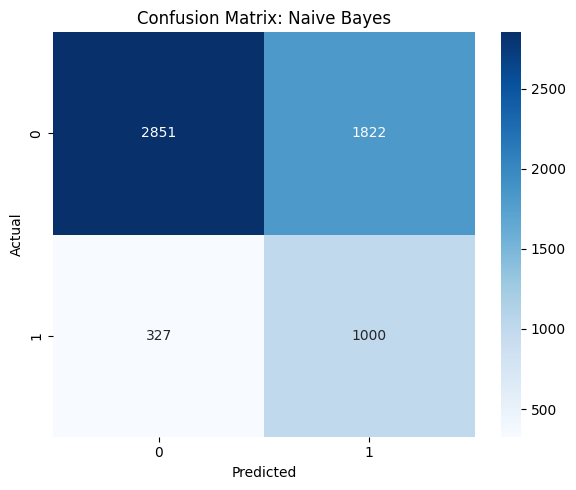


Random Forest:


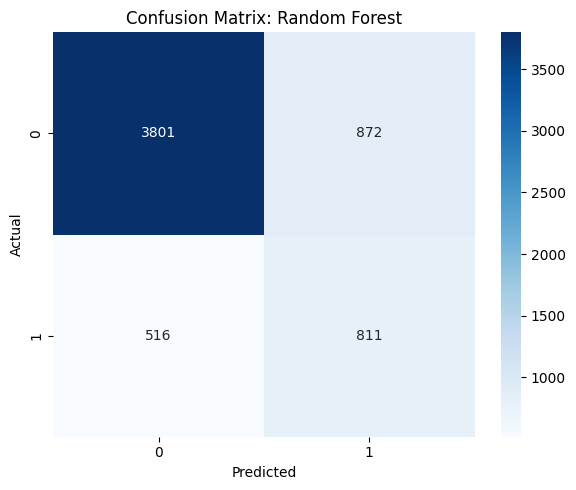

In [34]:
# Confusion Matrix Heatmaps
print("\n" + "="*80)
print("CONFUSION MATRICES")
print("="*80)

for name, cm in confusion_matrices.items():
    print(f"\n{name}:")

    # Create a heatmap (like your screenshot)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
                xticklabels=class_labels, yticklabels=class_labels, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix: {name}')

    # Display the plot
    plt.tight_layout()
    plt.show()

In [35]:
print("\n" + "="*80)
print("CLASSIFICATION REPORTS")
print("="*80)

for name, report in reports.items():
    print(f"\n{name}:")
    print(report)


CLASSIFICATION REPORTS

Logistic Regression:
              precision    recall  f1-score   support

           0       0.88      0.70      0.78      4673
           1       0.39      0.67      0.49      1327

    accuracy                           0.69      6000
   macro avg       0.63      0.68      0.63      6000
weighted avg       0.77      0.69      0.72      6000


Decision Tree:
              precision    recall  f1-score   support

           0       0.88      0.73      0.80      4673
           1       0.40      0.64      0.50      1327

    accuracy                           0.71      6000
   macro avg       0.64      0.69      0.65      6000
weighted avg       0.77      0.71      0.73      6000


KNN:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.74      0.65      0.67      6000
weight

In [36]:
print("\n" + "="*80)
print("OVERALL WINNER")
print("="*80)

best_accuracy = df_results['Accuracy'].max()
best_accuracy_model = df_results[df_results['Accuracy'] == best_accuracy].index[0]

best_auc = df_results['AUC'].max()
best_auc_model = df_results[df_results['AUC'] == best_auc].index[0]

print(f"\n🏆 Highest Accuracy: {best_accuracy_model} with {best_accuracy:.4%}")
print(f"🏆 Highest AUC: {best_auc_model} with {best_auc:.4f}")

if best_accuracy_model == best_auc_model:
    print(f"\n✅ **Overall Winner: {best_accuracy_model}** (Highest Accuracy and AUC)")
else:
    print(f"\n✅ **Overall Winner (by Accuracy): {best_accuracy_model}**")
    print(f"   Note: {best_auc_model} has the highest AUC, but accuracy is the primary metric for this dataset.")


OVERALL WINNER

🏆 Highest Accuracy: KNN with 81.2300%
🏆 Highest AUC: Random Forest with 0.7874

✅ **Overall Winner (by Accuracy): KNN**
   Note: Random Forest has the highest AUC, but accuracy is the primary metric for this dataset.


In [37]:
# Summary of Saved Files
print("\n" + "="*60)
print("SUMMARY OF SAVED FILES")
print("="*60)

saved_files = [
    'models/logistic_risk_v1.joblib',
    'models/decision_tree_v1.joblib',
    'models/knn_v1.joblib',
    'models/naive_bayes_v1.joblib',
    'models/random_forest_v1.joblib',
    'models/scaler.joblib',
    'models/feature_columns.joblib',
    'test_data.csv',
    'model_comparison.csv'
]

for file in saved_files:
    if os.path.exists(file):
        size = round(os.path.getsize(file) / 1024, 2)  # KB
        print(f"   ✅ {file} ({size} KB)")
    else:
        print(f"   ❌ {file} (MISSING)")

print("\n" + "="*60)
print("✅ ALL TASKS COMPLETE!")
print("="*60)


SUMMARY OF SAVED FILES
   ✅ models/logistic_risk_v1.joblib (2.45 KB)
   ✅ models/decision_tree_v1.joblib (48.53 KB)
   ✅ models/knn_v1.joblib (5252.15 KB)
   ✅ models/naive_bayes_v1.joblib (2.97 KB)
   ✅ models/random_forest_v1.joblib (7072.89 KB)
   ✅ models/scaler.joblib (1.82 KB)
   ✅ models/feature_columns.joblib (0.52 KB)
   ✅ test_data.csv (839.58 KB)
   ✅ model_comparison.csv (0.31 KB)

✅ ALL TASKS COMPLETE!
